In [2]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     ------------ -------------------------- 92.2/294.9 kB 2.6 MB/s eta 0:00:01
     ------------------------- ------------ 194.6/294.9 kB 2.4 MB/s eta 0:00:01
     ----------------------------- -------- 225.3/294.9 kB 2.3 MB/s eta 0:00:01
     ------------------------------------ - 286.7/294.9 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 1.5 MB/s eta 0:00:00
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
     ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
     ---------------------------------------- 70.6/70.6 kB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
      --------------------------------------- 0.1/7.2 MB 4.0 MB/s eta 0:00:02
     - -------------------------------------- 0.2/7.2 MB 3.0 MB/s eta 0:00:03
     -- ------

Loading training data from: artifacts/03_train.csv
Train Shape: (77176, 19)

--- Columns & Data Types ---
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
total_price                      float64
total_freight                    float64
total_items_count                float64
total_payment_value              float64
payment_installments_max         float64
payment_types_count              float64
is_late                            int64
dtype: object

--- Missing Values Summary ---
                              Missing_Count  Percentage
order_approve

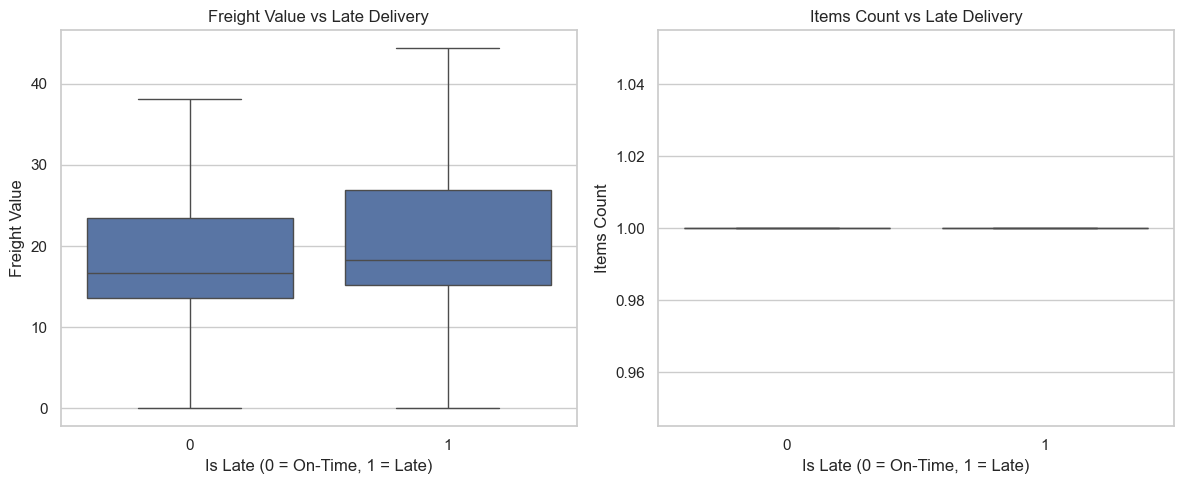


--- Top 5 States with Highest Late Delivery Rate (min 100 orders) ---
customer_state
AL    27.492447
MA    20.764120
SE    18.918919
CE    18.233083
PI    16.326531
Name: late_rate, dtype: float64


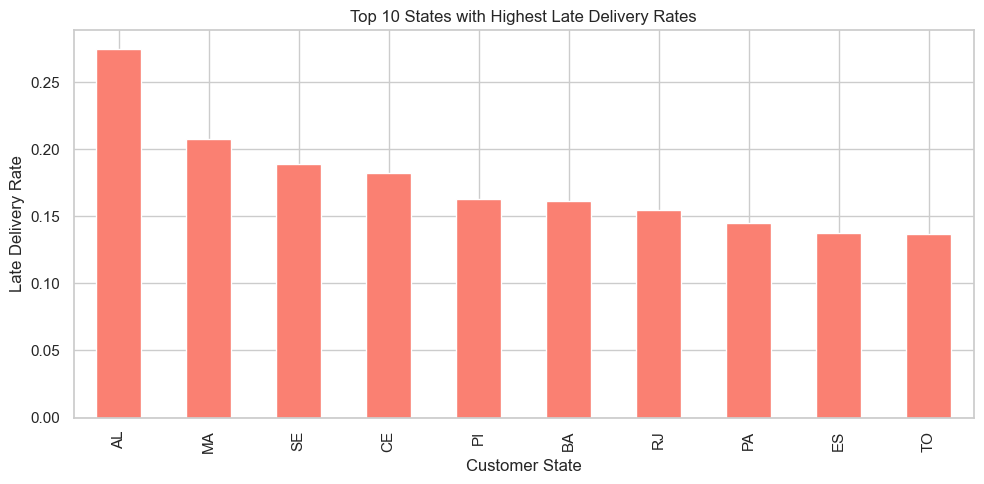


EDA completed. Plots saved to 'artifacts/eda_plots/'.


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plots styling and output directory
os.makedirs("artifacts/eda_plots", exist_ok=True)
sns.set_theme(style="whitegrid")

# 1. Load ONLY the training set
train_path = "artifacts/03_train.csv"
print(f"Loading training data from: {train_path}")
df_train = pd.read_csv(train_path)

print(f"Train Shape: {df_train.shape}")
print("\n--- Columns & Data Types ---")
print(df_train.dtypes)

# 2. Missing Values Analysis
print("\n--- Missing Values Summary ---")
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0])

# 3. Numeric Features Summary
numeric_cols = ['total_price', 'total_freight', 'total_items_count', 'total_payment_value']
print("\n--- Numerical Summary ---")
print(df_train[numeric_cols].describe().T)

# 4. Target vs Price & Freight (Relationship Analysis)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='is_late', y='total_freight', data=df_train, showfliers=False)
plt.title('Freight Value vs Late Delivery')
plt.xlabel('Is Late (0 = On-Time, 1 = Late)')
plt.ylabel('Freight Value')

plt.subplot(1, 2, 2)
sns.boxplot(x='is_late', y='total_items_count', data=df_train, showfliers=False)
plt.title('Items Count vs Late Delivery')
plt.xlabel('Is Late (0 = On-Time, 1 = Late)')
plt.ylabel('Items Count')

plt.tight_layout()
plt.savefig("artifacts/eda_plots/numerical_vs_target.png")
plt.show()

# 5. Geographic Analysis (Top States by Late Rate)
state_late = df_train.groupby('customer_state').agg(
    order_count=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).query('order_count >= 100').sort_values('late_rate', ascending=False)

print("\n--- Top 5 States with Highest Late Delivery Rate (min 100 orders) ---")
print((state_late['late_rate'] * 100).head(5))

plt.figure(figsize=(10, 5))
state_late['late_rate'].head(10).plot(kind='bar', color='salmon')
plt.title('Top 10 States with Highest Late Delivery Rates')
plt.ylabel('Late Delivery Rate')
plt.xlabel('Customer State')
plt.tight_layout()
plt.savefig("artifacts/eda_plots/state_late_rates.png")
plt.show()

print("\nEDA completed. Plots saved to 'artifacts/eda_plots/'.")